# Hourly Variability Sources — GEMS TCO  (2023 excluded)

**분석 목적**: hourly grouping (h0–h7) 했을 때 variability의 출처가 시간대별로 달라지는가?

| 분석 | 지표 | 질문 |
|------|------|------|
| **1** | γ̄_s(lag=1, h) — per-day 평균 short-lag spatial semivariogram | 소규모 공간 roughness가 시간대에 따라 달라지나? |
| **3** | 8×8 공분산 행렬 C[h₁,h₂] — day-to-day variability of spatial mean | 공간평균 자체가 시간대별로 얼마나 날마다 변하는가? |
| **4** | E_d[Var_x(h)] — per-day 공간분산의 평균 | 시간대별 전형적 공간 이질성은 얼마인가? |

**Analysis 4가 진정한 spatial variability인 이유**
- 각 날(d)·슬롯(h)의 공간 분산을 따로 구한 뒤 날에 대해 평균 → E_d[Var_x(h)]
- 날을 합쳐서(pooling) 한꺼번에 분산을 구하면 "날마다 공간 구조가 동일하다"는 가정 필요 → 현실과 불일치
- 날별 평균 후 집계하면 day-to-day temporal variability가 자연히 제거되고 슬롯별 공간 변동성만 남음

**데이터**: GEMS TCO, 2022/2024/2025 (2023 제외), 4–9월, lat [−3, 2], lon [121, 131]

In [1]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pathlib import Path

warnings.filterwarnings('ignore')

sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")
from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed

YEARS         = ['2022', '2024', '2025']
MONTHS        = [4, 5, 6, 7, 8, 9]
LAT_RANGE     = [-3.0, 2.0]
LON_RANGE     = [121.0, 131.0]
MM_COND       = 10
SLOTS_PER_DAY = 8
N_SLOTS       = 8
MONTH_NAMES   = {4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep'}
SLOT_LABELS   = [f'h{h}' for h in range(N_SLOTS)]

# ── Shared color palettes (defined once, used everywhere) ─────────────────────
# Blues h0→h7 (slot colors)
blues = cm.Blues(np.linspace(0.30, 0.95, N_SLOTS))
# RdYlGn_r Apr→Sep (month colors)
month_colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(MONTHS)))
MONTH_LABELS = [MONTH_NAMES[m] for m in MONTHS]   # ['Apr','May','Jun','Jul','Aug','Sep']

OUT_DIR = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/hourly_variability_sources/")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Setup done.")

Setup done.


In [2]:
# ── Data loading ──────────────────────────────────────────────────────────────
# 처음 한 번만 계산 후 pkl 캐시 저장 → 이후 실행은 즉시 로드
#
# 로딩 시 NNS Map 생성은 data_loader 내부에서 불가피하게 발생하나,
# 캐시 후에는 건너뜀.
#
# 필요 컬럼: ColumnAmountO3, Hours_elapsed, Latitude, Longitude

CACHE_PATH = OUT_DIR / "df_spatial_stats_no2023_cache.pkl"

def slot_spatial_sem_lag1(df_slot):
    """
    γ_s(lag=1) in lat and lon directions for a single (day, slot) observation.
    Column names: 'Latitude', 'Longitude', 'ColumnAmountO3'
    """
    d = pd.DataFrame({
        'lat': pd.to_numeric(df_slot['Latitude'],       errors='coerce'),
        'lon': pd.to_numeric(df_slot['Longitude'],      errors='coerce'),
        'o3':  pd.to_numeric(df_slot['ColumnAmountO3'], errors='coerce'),
    }).dropna()
    if len(d) < 4:
        return np.nan, np.nan
    gammas_lat = []
    for _, grp in d.groupby('lon'):
        vals = grp.sort_values('lat')['o3'].values
        gammas_lat.extend([(vals[i+1] - vals[i])**2 / 2 for i in range(len(vals)-1)])
    gammas_lon = []
    for _, grp in d.groupby('lat'):
        vals = grp.sort_values('lon')['o3'].values
        gammas_lon.extend([(vals[i+1] - vals[i])**2 / 2 for i in range(len(vals)-1)])
    return (
        float(np.mean(gammas_lat)) if gammas_lat else np.nan,
        float(np.mean(gammas_lon)) if gammas_lon else np.nan,
    )


def load_spatial_stats():
    data_loader = load_data_dynamic_processed(config.mac_data_load_path)
    records = []
    for yr in YEARS:
        for mo in MONTHS:
            print(f"  Loading {yr}-{mo:02d}...", flush=True)
            df_map, _, _, _ = data_loader.load_maxmin_ordered_data_bymonthyear(
                lat_lon_resolution=[1, 1], mm_cond_number=MM_COND,
                years_=[yr], months_=[mo],
                lat_range=LAT_RANGE, lon_range=LON_RANGE,
                is_whittle=False)
            sorted_keys = sorted(df_map.keys())
            n_days = len(sorted_keys) // SLOTS_PER_DAY
            for d_idx in range(n_days):
                day_keys = sorted_keys[d_idx * SLOTS_PER_DAY:(d_idx + 1) * SLOTS_PER_DAY]
                for slot, key in enumerate(day_keys):
                    df_slot = df_map[key]
                    o3    = pd.to_numeric(df_slot['ColumnAmountO3'], errors='coerce').dropna()
                    hours = pd.to_numeric(df_slot['Hours_elapsed'],  errors='coerce').dropna()
                    if len(o3) == 0 or len(hours) == 0:
                        continue
                    g_lat, g_lon = slot_spatial_sem_lag1(df_slot)
                    records.append({
                        'year':          int(yr),
                        'month':         mo,
                        'day_idx':       d_idx,
                        'slot':          slot,
                        'hours_elapsed': float(hours.median()),
                        'spatial_mean':  float(o3.mean()),
                        'spatial_std':   float(o3.std()),
                        'sem_lat_lag1':  g_lat,
                        'sem_lon_lag1':  g_lon,
                        'n_obs':         int(len(o3)),
                    })
    df_out = pd.DataFrame(records).sort_values('hours_elapsed').reset_index(drop=True)
    df_out['spatial_mean_c'] = df_out.groupby(['year', 'month'])['spatial_mean'].transform(
        lambda x: x - x.mean())
    return df_out


def build_hourly_matrix(df):
    """Y (n_days × 8) — centered spatial means, for 8×8 cov matrix."""
    day_order = (df.groupby(['year', 'month', 'day_idx'])['hours_elapsed']
                   .min().reset_index().sort_values('hours_elapsed'))
    mat_rows, day_meta = [], []
    for _, row in day_order.iterrows():
        yr, mo, d_idx = int(row['year']), int(row['month']), int(row['day_idx'])
        sub = df[(df['year'] == yr) & (df['month'] == mo) & (df['day_idx'] == d_idx)]
        vec = np.full(SLOTS_PER_DAY, np.nan)
        for _, r in sub.iterrows():
            vec[int(r['slot'])] = r['spatial_mean_c']
        mat_rows.append(vec)
        day_meta.append((yr, mo, d_idx))
    return np.array(mat_rows), day_meta


# ── 캐시 로드 or 새로 계산 ─────────────────────────────────────────────────────
if CACHE_PATH.exists():
    print(f"Cache found — loading from {CACHE_PATH.name}")
    df = pd.read_pickle(CACHE_PATH)
    print(f"Loaded: {len(df)} rows")
else:
    print("No cache found. Computing (NNS Map 생성 포함, 약 10–15분)...")
    df = load_spatial_stats()
    df.to_pickle(CACHE_PATH)
    print(f"Saved cache → {CACHE_PATH}")

Y, day_meta = build_hourly_matrix(df)
n_days, n_slots = Y.shape
print(f"Y shape: {Y.shape},  NaN: {np.isnan(Y).mean()*100:.1f}%")

Cache found — loading from df_spatial_stats_no2023_cache.pkl
Loaded: 4344 rows
Y shape: (543, 8),  NaN: 0.0%


---
## Analysis 1 — Short-Lag Spatial Semivariogram by Hour

날별로 γ_d(lag=1, h) 를 구한 뒤 날에 대해 평균:

$$\bar{\gamma}_s(\text{lag=1},\, h) = \frac{1}{D}\sum_{d=1}^{D} \hat{\gamma}_d(\text{lag=1},\, h)$$

$$\hat{\gamma}_d(\text{lag=1},\, h) = \frac{1}{2|P|}\sum_{(i,j)\in P}\left[Z(s_i,h,d) - Z(s_j,h,d)\right]^2$$

- 날마다 독립적으로 γ_d 계산 후 평균 → pooling 없음
- 공간 구조가 날마다 달라도 무방
- **이 값이 시간대별로 다르면** 소규모 공간 roughness가 diurnal cycle을 가짐

In [3]:
# ── Analysis 1: per-day averaged short-lag semivariogram by slot ─────────────
# df['sem_lat_lag1'], df['sem_lon_lag1']: per-(day,slot) γ(lag=1)
# → groupby slot + mean = E_d[γ_d(lag=1, h)]  (no pooling)

an1_lat = df.groupby('slot')['sem_lat_lag1'].mean().values   # shape (8,)
an1_lon = df.groupby('slot')['sem_lon_lag1'].mean().values

print(f"γ̄_s(lag=1) per slot  [per-day average]:")
print(f"{'slot':>5}  {'lat':>10}  {'lon':>10}")
for h in range(N_SLOTS):
    print(f"  h{h}    {an1_lat[h]:>10.4f}  {an1_lon[h]:>10.4f}")

γ̄_s(lag=1) per slot  [per-day average]:
 slot         lat         lon
  h0        4.1508      4.2540
  h1        4.4586      4.5866
  h2        4.4117      4.6128
  h3        4.3468      4.6465
  h4        4.4369      4.8307
  h5        4.3767      4.8316
  h6        3.6512      4.1091
  h7        3.3419      3.6805


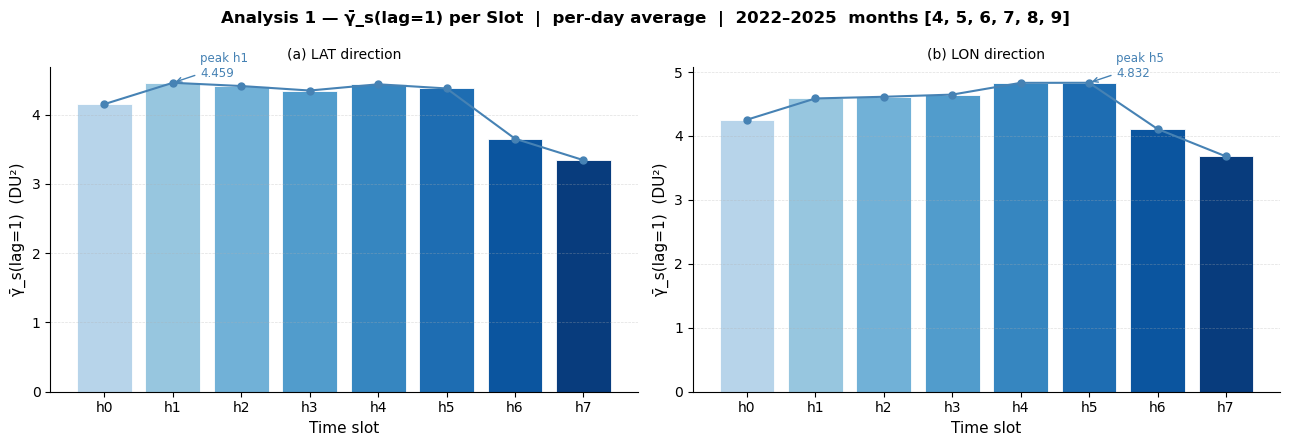

In [4]:
# ── Analysis 1 시각화 ─────────────────────────────────────────────────────────
blues = cm.Blues(np.linspace(0.30, 0.95, N_SLOTS))
x = np.arange(N_SLOTS)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(
    f'Analysis 1 — γ̄_s(lag=1) per Slot  |  per-day average  |  '
    f'{YEARS[0]}–{YEARS[-1]}  months {MONTHS}',
    fontsize=12, fontweight='bold'
)

for ax, vals, direction in [
    (axes[0], an1_lat, 'LAT'),
    (axes[1], an1_lon, 'LON'),
]:
    ax.bar(x, vals, color=[blues[h] for h in range(N_SLOTS)],
           edgecolor='white', lw=0.6)
    ax.plot(x, vals, 'o-', color='steelblue', lw=1.5, ms=5, zorder=5)
    peak_h = int(np.argmax(vals))
    ax.annotate(f'peak h{peak_h}\n{vals[peak_h]:.3f}',
                xy=(peak_h, vals[peak_h]),
                xytext=(peak_h + 0.4, vals[peak_h] + 0.02 * vals.max()),
                fontsize=8.5, color='steelblue',
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.0))
    ax.set_xticks(x); ax.set_xticklabels([f'h{h}' for h in range(N_SLOTS)], fontsize=10)
    ax.set_xlabel('Time slot', fontsize=11)
    ax.set_ylabel('γ̄_s(lag=1)  (DU²)', fontsize=11)
    ax.set_title(f'({["a","b"][axes.tolist().index(ax)]}) {direction} direction', fontsize=10)
    ax.set_ylim(bottom=0)
    ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / 'an1_spatial_sem_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

slot     h0     h1     h2     h3     h4     h5     h6     h7
Apr   5.009  4.917  4.687  4.551  4.789  5.243  4.372  3.980
May   4.002  4.581  4.645  4.549  4.680  4.426  3.751  3.075
Jun   3.606  4.283  4.511  4.501  4.433  3.986  3.357  2.689
Jul   3.351  3.834  3.916  3.939  3.920  3.745  3.096  2.795
Aug   3.926  4.077  4.012  3.821  3.686  3.654  3.359  3.743
Sep   5.034  5.074  4.707  4.730  5.129  5.229  3.983  3.782
All   4.151  4.459  4.412  4.347  4.437  4.377  3.651  3.342


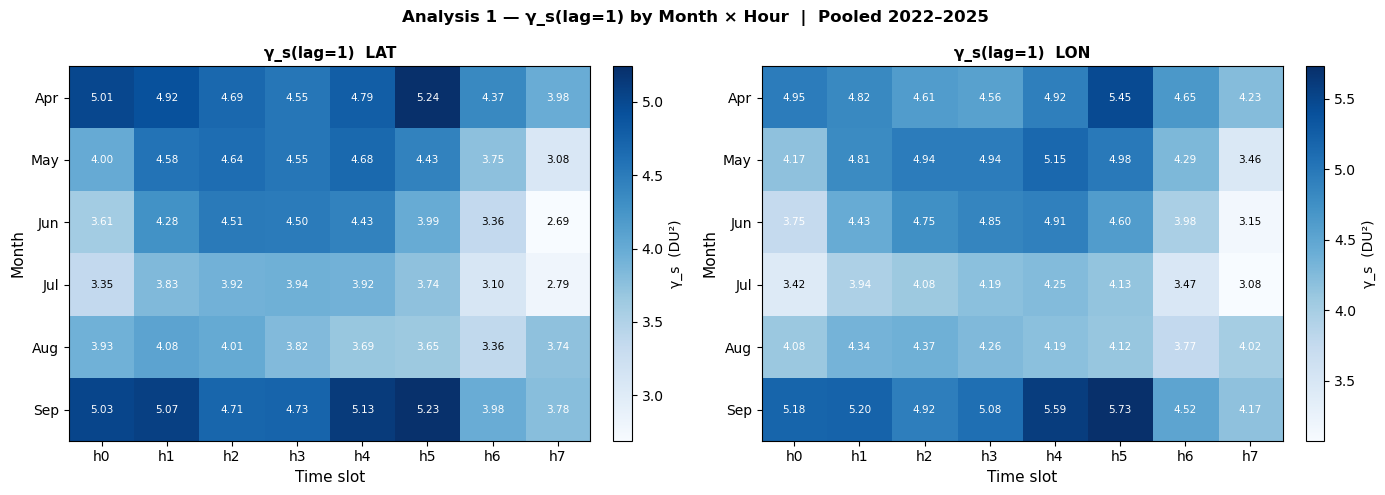

In [5]:
# ── Analysis 1: Monthly × hour heatmap of γ_s(lag=1) ─────────────────────────

an1_monthly_lat = (
    df.groupby(["month", "slot"])["sem_lat_lag1"].mean()
      .unstack("slot").rename(columns=lambda h: f"h{int(h)}")
      .reindex(MONTHS)
)
an1_monthly_lat.index = [MONTH_NAMES[m] for m in an1_monthly_lat.index]

an1_monthly_lon = (
    df.groupby(["month", "slot"])["sem_lon_lag1"].mean()
      .unstack("slot").rename(columns=lambda h: f"h{int(h)}")
      .reindex(MONTHS)
)
an1_monthly_lon.index = [MONTH_NAMES[m] for m in an1_monthly_lon.index]

# ── Overall (all months pooled) row 추가 ──────────────────────────────────────
_all_lat = df.groupby("slot")["sem_lat_lag1"].mean().rename(lambda h: f"h{int(h)}")
_all_lon = df.groupby("slot")["sem_lon_lag1"].mean().rename(lambda h: f"h{int(h)}")
an1_monthly_lat = pd.concat([an1_monthly_lat,
                              pd.DataFrame([_all_lat.values], index=["All"], columns=_all_lat.index)])
an1_monthly_lon = pd.concat([an1_monthly_lon,
                              pd.DataFrame([_all_lon.values], index=["All"], columns=_all_lon.index)])

# ── Rows for heatmap: months only (no All row) + display ─────────────────────
an1_heatmap_lat = an1_monthly_lat.drop(index="All")
an1_heatmap_lon = an1_monthly_lon.drop(index="All")

print(an1_monthly_lat.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Analysis 1 — γ_s(lag=1) by Month × Hour  |  '
    f'Pooled {YEARS[0]}–{YEARS[-1]}',
    fontsize=12, fontweight='bold'
)

for ax, mat, direction in [(axes[0], an1_heatmap_lat, 'LAT'), (axes[1], an1_heatmap_lon, 'LON')]:
    vals = mat.values.astype(float)
    im = ax.imshow(vals, cmap='Blues', aspect='auto')
    ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels([f'h{h}' for h in range(N_SLOTS)])
    ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
    ax.set_xlabel('Time slot', fontsize=11); ax.set_ylabel('Month', fontsize=11)
    ax.set_title(f'γ_s(lag=1)  {direction}', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='γ_s  (DU²)')
    vmax = np.nanmax(vals)
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            if np.isfinite(vals[i, j]):
                ax.text(j, i, f'{vals[i,j]:.2f}', ha='center', va='center', fontsize=7.5,
                        color='white' if vals[i, j] > vmax * 0.65 else 'black')

plt.tight_layout()
plt.savefig(OUT_DIR / 'an1_spatial_sem_monthly_heatmap_no2023.png', dpi=150, bbox_inches='tight')
plt.show()

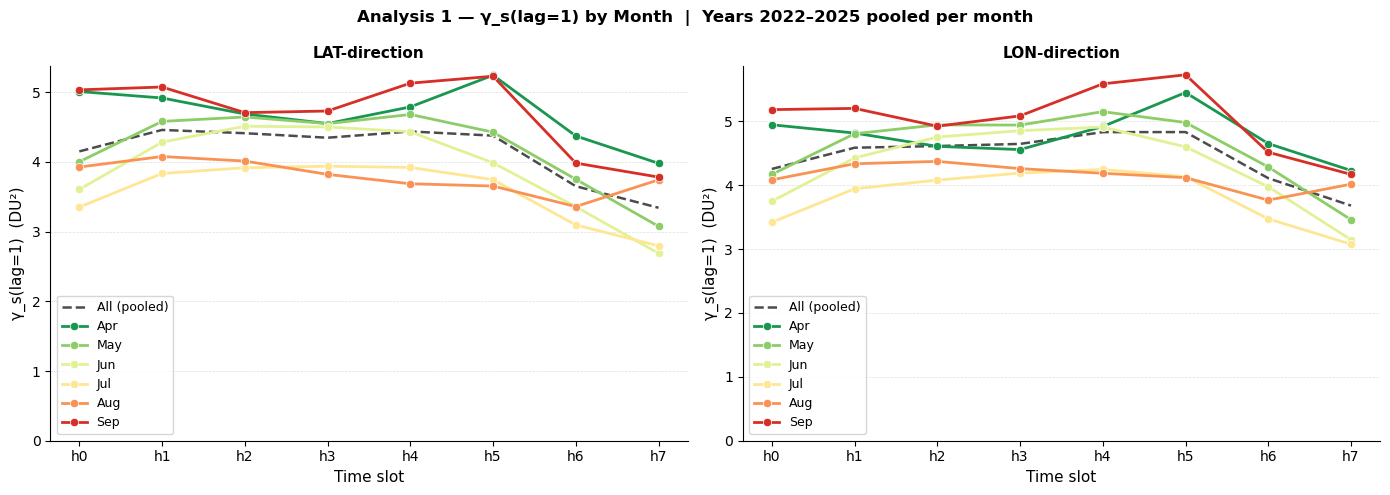

Saved: an1_spatial_sem_monthly_lines_no2023.png


In [6]:
# ── Analysis 1: Monthly line plot — γ_s(lag=1) ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Analysis 1 — γ_s(lag=1) by Month  |  '
    f'Years {YEARS[0]}–{YEARS[-1]} pooled per month',
    fontsize=12, fontweight='bold'
)

for ax, monthly_df, direction in [
    (axes[0], an1_monthly_lat, 'LAT'),
    (axes[1], an1_monthly_lon, 'LON'),
]:
    # All-months pooled: 굵은 검정 점선 배경 기준선 (zorder=1)
    all_row = monthly_df.loc['All'].values.astype(float)
    ax.plot(range(N_SLOTS), all_row, 'k--',
            lw=1.8, alpha=0.7,
            label='All (pooled)', zorder=2)

    # Monthly lines: 전경 (zorder=5+)
    for i, mo in enumerate(MONTHS):
        mname = MONTH_NAMES[mo]
        row = monthly_df.loc[mname].values.astype(float)
        ax.plot(range(N_SLOTS), row, 'o-',
                color=month_colors[i], lw=2.0, ms=6,
                markeredgecolor='white', markeredgewidth=0.5,
                label=mname, zorder=5 + i)

    ax.set_xticks(range(N_SLOTS))
    ax.set_xticklabels(SLOT_LABELS, fontsize=10)
    ax.set_xlabel('Time slot', fontsize=11)
    ax.set_ylabel('γ_s(lag=1)  (DU²)', fontsize=11)
    ax.set_title(f'{direction}-direction', fontsize=11, fontweight='bold')
    ax.set_ylim(bottom=0)
    ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.8, loc='best')

plt.tight_layout()
plt.savefig(OUT_DIR / 'an1_spatial_sem_monthly_lines_no2023.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: an1_spatial_sem_monthly_lines_no2023.png")

---
## Analysis 3 — 8×8 Covariance Matrix: Day-to-Day Variability of Spatial Mean

$$\hat{C}[h_1, h_2] = \frac{1}{n} \sum_{d=1}^{n} \bar{Y}[d, h_1] \cdot \bar{Y}[d, h_2]$$

- $\bar{Y}[d, h]$: $d$번째 날 $h$번째 슬롯의 **공간평균** (year-month 내 centered)
- **대각원소 $\hat{C}[h,h]$**: 시간대 $h$에서 공간평균의 day-to-day 분산
- Analysis 1, 2와 달리 **시간(날짜) 방향** variability → α(t) 필요 여부와 직접 연관

> Analysis 1, 2가 diurnal pattern을 보인다면:  
> `Z(x,t,d) = μ(x,t) + α(t)·η(x,d) + ε(x,t,d)` 형태 검토  
> Analysis 3에서 `C[h,h]`가 시간대별로 다르면 `α(t)` 자체가 diurnal scaling을 가짐

In [7]:
# ── Analysis 3: 8×8 공분산 행렬 ──────────────────────────────────────────────

def sample_cov_matrix(Y):
    n_s = Y.shape[1]
    C = np.full((n_s, n_s), np.nan)
    for h1 in range(n_s):
        for h2 in range(n_s):
            mask = np.isfinite(Y[:, h1]) & np.isfinite(Y[:, h2])
            if mask.sum() > 1:
                C[h1, h2] = np.mean(Y[mask, h1] * Y[mask, h2])
    return C


def toeplitz_check(C):
    n = C.shape[0]
    rows = []
    for k in range(n):
        diag_vals = np.array([C[h, h+k] for h in range(n-k) if np.isfinite(C[h, h+k])])
        if len(diag_vals) == 0:
            continue
        mean_val, std_val = diag_vals.mean(), diag_vals.std()
        cv = std_val / abs(mean_val) if abs(mean_val) > 1e-10 else np.nan
        rows.append({'lag_k': k, 'n_elems': len(diag_vals),
                     'mean': round(mean_val, 4), 'std': round(std_val, 4),
                     'CV=std/|mean|': round(cv, 4) if np.isfinite(cv) else np.nan,
                     'values': np.round(diag_vals, 4).tolist()})
    return pd.DataFrame(rows)


C = sample_cov_matrix(Y)
df_toep = toeplitz_check(C)

# ── 데이터 범위 명시 ───────────────────────────────────────────────────────────
print(f"Data: years {YEARS},  months {MONTHS}  (all pooled)")
print(f"n_days = {n_days},  slots_per_day = {n_slots}")
print()
print("8×8 표본 공분산 행렬 C:")
print(pd.DataFrame(C, columns=SLOT_LABELS, index=SLOT_LABELS).round(4).to_string())
print("\nToeplitz 체크:")
print(df_toep[['lag_k','n_elems','mean','std','CV=std/|mean|']].to_string(index=False))

Data: years ['2022', '2024', '2025'],  months [4, 5, 6, 7, 8, 9]  (all pooled)
n_days = 543,  slots_per_day = 8

8×8 표본 공분산 행렬 C:
        h0      h1      h2      h3      h4      h5      h6       h7
h0  9.0041  8.8934  8.6444  8.2574  8.0821  7.9862  7.5145   7.3466
h1  8.8934  9.1807  9.1609  8.8485  8.6036  8.2600  7.5677   6.7743
h2  8.6444  9.1609  9.4432  9.2867  9.0121  8.4419  7.5708   6.1949
h3  8.2574  8.8485  9.2867  9.3695  9.0451  8.4390  7.5534   5.9886
h4  8.0821  8.6036  9.0121  9.0451  9.3026  8.6589  8.0586   6.6466
h5  7.9862  8.2600  8.4419  8.4390  8.6589  8.7890  8.3880   7.7752
h6  7.5145  7.5677  7.5708  7.5534  8.0586  8.3880  8.7254   8.6034
h7  7.3466  6.7743  6.1949  5.9886  6.6466  7.7752  8.6034  12.1299

Toeplitz 체크:
 lag_k  n_elems   mean    std  CV=std/|mean|
     0        8 9.4930 1.0264         0.1081
     1        7 8.8624 0.3017         0.0340
     2        6 8.4630 0.4321         0.0511
     3        5 7.9006 0.7222         0.0914
     4        4 7.4

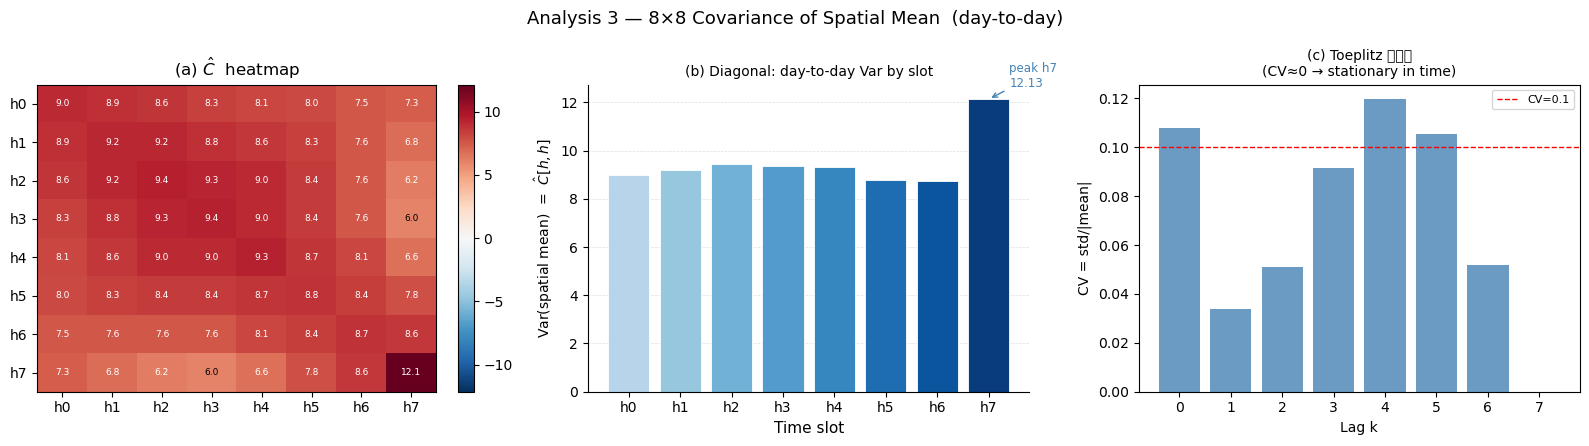

In [8]:
# ── Analysis 3 시각화 ─────────────────────────────────────────────────────────

diag_var = np.array([C[h, h] for h in range(N_SLOTS)])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Analysis 3 — 8×8 Covariance of Spatial Mean  (day-to-day)', fontsize=13)

# (a) Heatmap
ax = axes[0]
vmax = np.nanmax(np.abs(C))
im = ax.imshow(C, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
slot_labels = [f'h{i}' for i in range(8)]
ax.set_xticks(range(8)); ax.set_xticklabels(slot_labels)
ax.set_yticks(range(8)); ax.set_yticklabels(slot_labels)
ax.set_title('(a) $\\hat{C}$  heatmap')
plt.colorbar(im, ax=ax, fraction=0.046)
for i in range(8):
    for j in range(8):
        if np.isfinite(C[i, j]):
            ax.text(j, i, f'{C[i,j]:.1f}', ha='center', va='center', fontsize=6.5,
                    color='white' if abs(C[i,j]) > vmax*0.5 else 'black')

# (b) Diagonal: Var(spatial mean) by slot
ax = axes[1]
ax.bar(range(N_SLOTS), diag_var, color=[blues[h] for h in range(N_SLOTS)],
       edgecolor='white', lw=0.6)
ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels(slot_labels)
ax.set_xlabel('Time slot', fontsize=11)
ax.set_ylabel('Var(spatial mean)  =  $\\hat{C}[h,h]$', fontsize=10)
ax.set_title('(b) Diagonal: day-to-day Var by slot', fontsize=10)
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
peak_h = int(np.argmax(diag_var))
ax.annotate(f'peak h{peak_h}\n{diag_var[peak_h]:.2f}',
            xy=(peak_h, diag_var[peak_h]),
            xytext=(peak_h + 0.4, diag_var[peak_h] + 0.5),
            fontsize=8.5, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.0))

# (c) Toeplitz CV
ax = axes[2]
ax.bar(df_toep['lag_k'], df_toep['CV=std/|mean|'], color='steelblue', alpha=0.8)
ax.axhline(0.1, ls='--', color='red', lw=1, label='CV=0.1')
ax.set_xlabel('Lag k'); ax.set_ylabel('CV = std/|mean|')
ax.set_title('(c) Toeplitz 이탈도\n(CV≈0 → stationary in time)', fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'an3_cov_matrix_no2023.png', dpi=130, bbox_inches='tight')
plt.show()

In [9]:
# ── Analysis 3: Monthly breakdown — C[h,h] per month (years pooled) ──────────
# 각 월마다 (22,23,24,25년 합쳐서) Y 행렬 구성 → 대각원소 C[h,h] 계산
# → 어떤 월이 pooled 결과를 지배하는지 파악

def monthly_cov_diagonal(df):
    """
    For each month: build Y matrix (all years pooled for that month),
    compute C[h,h] diagonal.
    Returns DataFrame: (month × slot)
    """
    result = {}
    for mo in MONTHS:
        sub = df[df['month'] == mo].copy()
        day_order = (sub.groupby(['year', 'day_idx'])['hours_elapsed']
                       .min().reset_index().sort_values('hours_elapsed'))
        mat_rows = []
        for _, row in day_order.iterrows():
            yr, d_idx = int(row['year']), int(row['day_idx'])
            s = sub[(sub['year'] == yr) & (sub['day_idx'] == d_idx)]
            vec = np.full(N_SLOTS, np.nan)
            for _, r in s.iterrows():
                vec[int(r['slot'])] = r['spatial_mean_c']
            mat_rows.append(vec)
        Y_mo = np.array(mat_rows)
        diag = np.array([
            float(np.nanmean(Y_mo[:, h] ** 2)) if np.any(np.isfinite(Y_mo[:, h])) else np.nan
            for h in range(N_SLOTS)
        ])
        result[mo] = diag
    cols = [f'h{h}' for h in range(N_SLOTS)]
    df_out = pd.DataFrame(result, index=cols).T.reindex(MONTHS)
    df_out.index = [MONTH_NAMES[m] for m in df_out.index]
    return df_out

monthly_cov_diag = monthly_cov_diagonal(df)

# ── Overall (all months pooled) row 추가 ──────────────────────────────────────
all_diag = pd.Series(
    [C[h, h] for h in range(N_SLOTS)],
    index=[f'h{h}' for h in range(N_SLOTS)],
    name='All'
)
monthly_cov_diag = pd.concat([monthly_cov_diag,
                               all_diag.to_frame().T])

print("C[h,h] (Var of spatial mean) by month × slot:")
print(monthly_cov_diag.round(2).to_string())

C[h,h] (Var of spatial mean) by month × slot:
        h0     h1     h2     h3     h4     h5     h6     h7
Apr   8.45   9.41   9.64   9.57   9.28   8.98   8.72   9.88
May  13.20  13.46  13.29  12.85  13.10  13.05  13.94  16.75
Jun   6.20   6.21   6.79   6.94   6.57   6.63   6.01  10.79
Jul   8.91   8.69   9.06   9.02   8.35   8.29   7.36  11.11
Aug   9.51   9.66  10.38  10.34  11.52   8.50   9.32  10.25
Sep   7.64   7.53   7.39   7.39   6.87   7.18   6.88  13.95
All   9.00   9.18   9.44   9.37   9.30   8.79   8.73  12.13


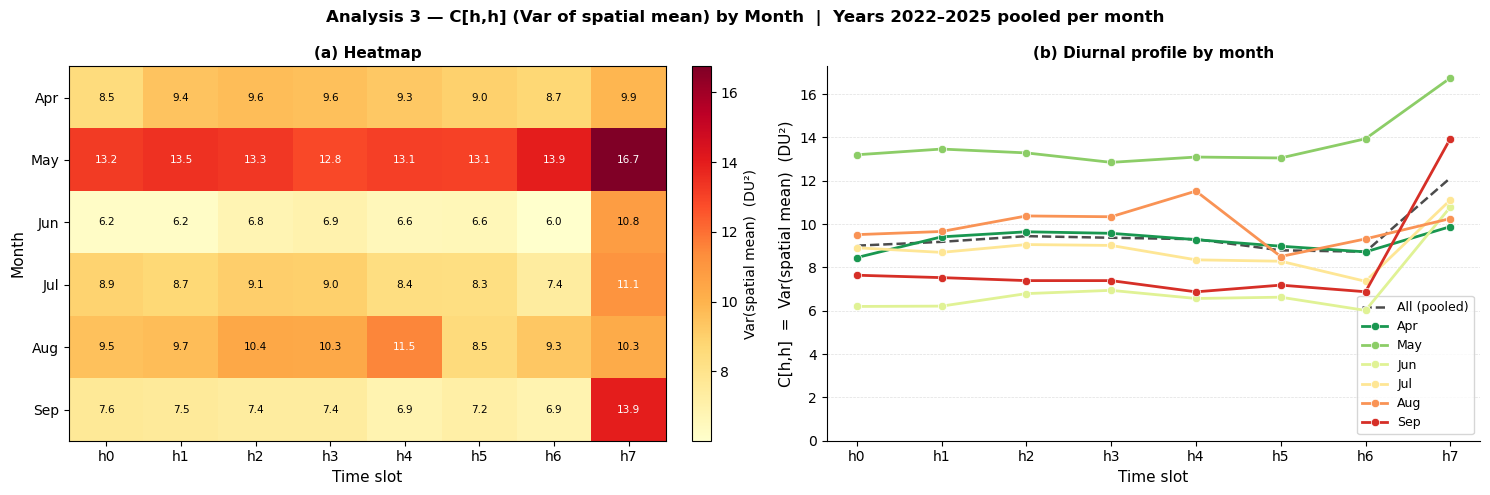

Saved: an3_cov_diag_monthly_no2023.png


In [10]:
# ── Analysis 3: Monthly C[h,h] heatmap + line plot ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f'Analysis 3 — C[h,h] (Var of spatial mean) by Month  |  '
    f'Years {YEARS[0]}–{YEARS[-1]} pooled per month',
    fontsize=12, fontweight='bold'
)

# (a) Heatmap — months only (no All row)
ax = axes[0]
heatmap_data = monthly_cov_diag.drop(index='All')
vals = heatmap_data.values.astype(float)
im = ax.imshow(vals, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels(SLOT_LABELS, fontsize=10)
ax.set_yticks(range(len(heatmap_data.index))); ax.set_yticklabels(heatmap_data.index, fontsize=10)
ax.set_xlabel('Time slot', fontsize=11)
ax.set_ylabel('Month', fontsize=11)
ax.set_title('(a) Heatmap', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Var(spatial mean)  (DU²)')
vmax = np.nanmax(vals)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        if np.isfinite(vals[i, j]):
            ax.text(j, i, f'{vals[i,j]:.1f}', ha='center', va='center', fontsize=7.5,
                    color='white' if vals[i, j] > vmax * 0.65 else 'black')

# (b) Line plot: All 기준선 + monthly 전경
ax = axes[1]
all_row = monthly_cov_diag.loc['All'].values.astype(float)

# All: 굵은 검정 점선 기준선 (zorder=2)
ax.plot(range(N_SLOTS), all_row, 'k--',
        lw=1.8, alpha=0.7,
        label='All (pooled)', zorder=2)

# Monthly lines: 전경 (zorder=5+)
for i, mo in enumerate(MONTHS):
    mname = MONTH_NAMES[mo]
    row = monthly_cov_diag.loc[mname].values.astype(float)
    ax.plot(range(N_SLOTS), row, 'o-',
            color=month_colors[i], lw=2.0, ms=6,
            markeredgecolor='white', markeredgewidth=0.5,
            label=mname, zorder=5 + i)

ax.set_xticks(range(N_SLOTS))
ax.set_xticklabels(SLOT_LABELS, fontsize=10)
ax.set_xlabel('Time slot', fontsize=11)
ax.set_ylabel('C[h,h]  =  Var(spatial mean)  (DU²)', fontsize=11)
ax.set_title('(b) Diurnal profile by month', fontsize=11, fontweight='bold')
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=9, framealpha=0.8, loc='best')

plt.tight_layout()
plt.savefig(OUT_DIR / 'an3_cov_diag_monthly_no2023.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: an3_cov_diag_monthly_no2023.png")

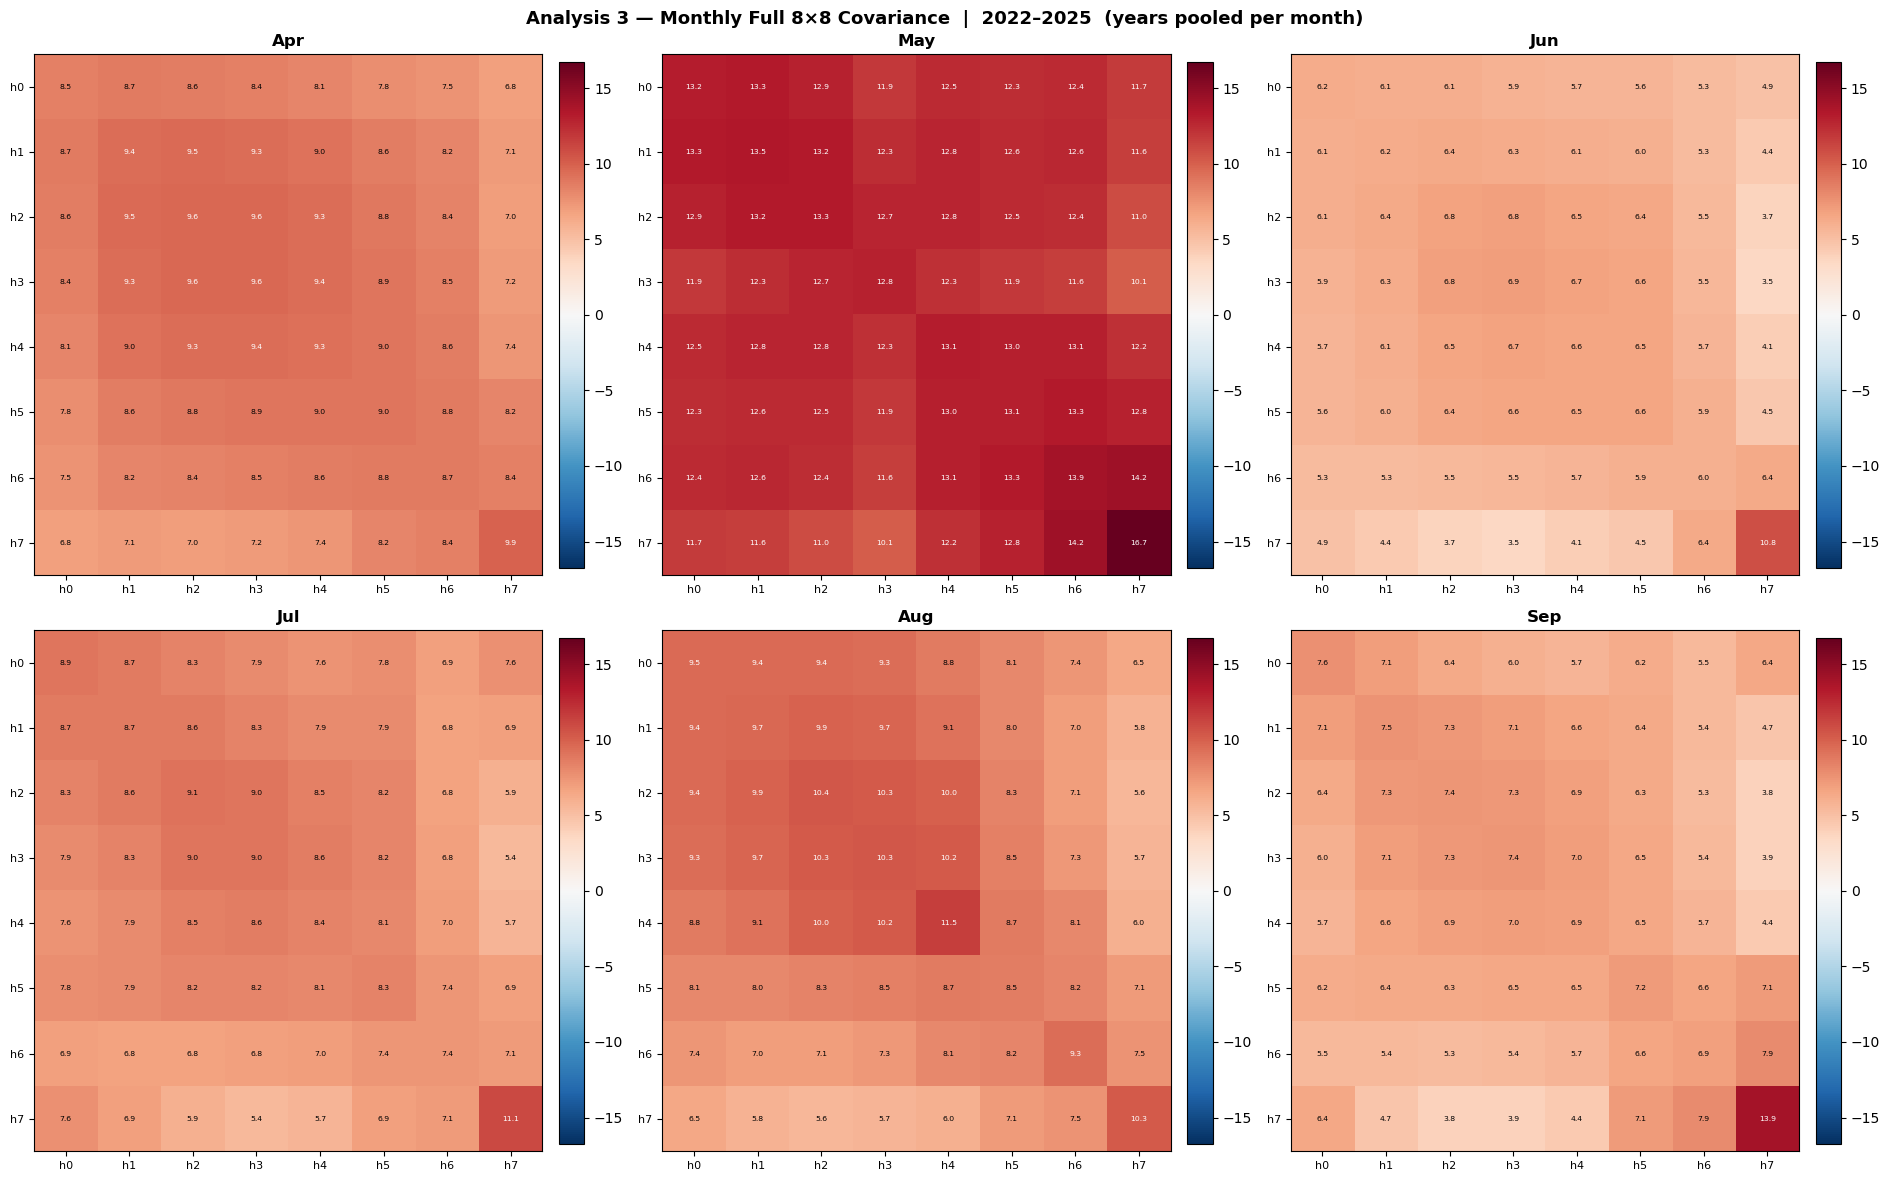

Saved → an3_monthly_full_cov.png


In [11]:
# ── Analysis 3: Monthly full 8×8 covariance matrix ───────────────────────────
# 각 월별로 Y 행렬 구성 → full sample_cov_matrix 적용

def monthly_cov_matrix(df):
    """Full 8×8 C per month (all years pooled within each month)."""
    result = {}
    for mo in MONTHS:
        sub = df[df['month'] == mo].copy()
        day_order = (sub.groupby(['year', 'day_idx'])['hours_elapsed']
                       .min().reset_index().sort_values('hours_elapsed'))
        mat_rows = []
        for _, row in day_order.iterrows():
            yr, d_idx = int(row['year']), int(row['day_idx'])
            s = sub[(sub['year'] == yr) & (sub['day_idx'] == d_idx)]
            vec = np.full(N_SLOTS, np.nan)
            for _, r in s.iterrows():
                vec[int(r['slot'])] = r['spatial_mean_c']
            mat_rows.append(vec)
        Y_mo = np.array(mat_rows)
        result[mo] = sample_cov_matrix(Y_mo)   # sample_cov_matrix defined in an3_compute
    return result

monthly_C = monthly_cov_matrix(df)

# ── 시각화: 2×3 grid, 월별 8×8 heatmap ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(19, 12))
fig.suptitle(
    f'Analysis 3 — Monthly Full 8×8 Covariance  |  '
    f'{YEARS[0]}–{YEARS[-1]}  (years pooled per month)',
    fontsize=13, fontweight='bold'
)
vmax_global = max(np.nanmax(np.abs(monthly_C[mo])) for mo in MONTHS)

for ax, mo in zip(axes.ravel(), MONTHS):
    C_mo = monthly_C[mo]
    im = ax.imshow(C_mo, cmap='RdBu_r', vmin=-vmax_global, vmax=vmax_global, aspect='auto')
    ax.set_title(MONTH_NAMES[mo], fontsize=12, fontweight='bold')
    ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels(SLOT_LABELS, fontsize=8)
    ax.set_yticks(range(N_SLOTS)); ax.set_yticklabels(SLOT_LABELS, fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    for h1 in range(N_SLOTS):
        for h2 in range(N_SLOTS):
            v = C_mo[h1, h2]
            if np.isfinite(v):
                ax.text(h2, h1, f'{v:.1f}', ha='center', va='center', fontsize=5.5,
                        color='white' if abs(v) > vmax_global * 0.55 else 'black')

plt.tight_layout()
plt.savefig(OUT_DIR / 'an3_monthly_full_cov.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → an3_monthly_full_cov.png")


---
## 모델링 판단

### 분석 결과 → 모델 선택 흐름

```
Analysis 1 γ̄_s(h) 시간대별 차이?  +  Analysis 4 E_d[Var_x(h)] 시간대별 차이?
         │                                      │
   둘 다 유의미한 diurnal                  둘 다 일정
         │                                      │
   공간 구조가 diurnal cycle              공간 구조는 time-invariant
         │                                      │
   α(t)·[Z(x,t,d) − μ(x,t)]            β(t,d) + ε(x,t,d)
   (diurnal scaling of spatial field)   (mean만 시간 변동)
```

### Analysis 3과의 연결

- `C[h,h]`가 시간대별로 **일정** → α(t)=const, scaling 불필요  
  → `Z(x,t,d) = μ(x,t) + η(x,d) + ε(x,t,d)`
- `C[h,h]`가 시간대별로 **달라짐** → 날마다의 변동 크기 자체가 시간대에 따라 다름  
  → `Z(x,t,d) = μ(x,t) + α(t)·η(x,d) + ε(x,t,d)`
- Analysis 1, 4도 함께 커진다면 → α(t)는 공간 구조 전체를 scaling
- Analysis 1, 4가 일정한데 C[h,h]만 다르면 → overall level만 α(t)로 scaling (spatial pattern 고정)

---
## Analysis 4 — Pure Spatial Variability by Hour

$$E_d\left[\text{Var}_x\left(Z(x,\,h,\,d)\right)\right] = \frac{1}{D}\sum_{d=1}^{D} \text{Var}_x\left[Z(x,\,h,\,d)\right]$$

- 각 날(d)·슬롯(h)의 공간 분산을 독립적으로 계산 후 날에 대해 단순 평균
- pooling 없음 → "날마다 공간 구조가 같다"는 가정 불필요
- 날별 평균으로 day-to-day temporal variability가 제거 → **슬롯별 순수 공간 변동성**
- Analysis 1 γ̄_s(lag=1)은 고주파(소규모) 변동, Analysis 4는 전대역 공간 변동

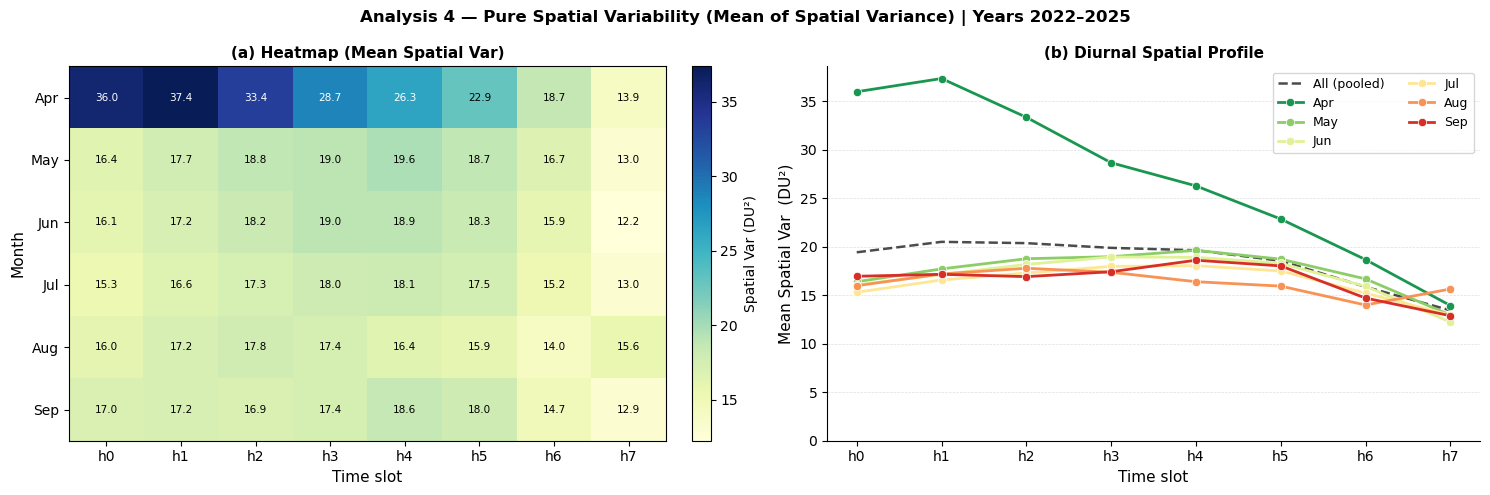

In [12]:
# ── Analysis 4: Pure Spatial Variability (Mean of spatial variance) ──────────

# 1. 이미 데이터에 있는 spatial_std를 사용하여 공간 분산(Variance) 열 생성
df['spatial_var'] = df['spatial_std'] ** 2

# 2. 월별/슬롯(slot)별로 공간 분산의 '평균'을 구함
# (이것이 해당 월/시간대에 평균적으로 지역 간 편차가 얼마나 발생하는지를 나타냄)
monthly_spatial_var = df.groupby(['month', 'slot'])['spatial_var'].mean().unstack()

# 3. 'All' (전체 기간 평균) 계산 및 추가
all_spatial_var = df.groupby('slot')['spatial_var'].mean()
monthly_spatial_var.loc['All'] = all_spatial_var.values

# 4. 인덱스를 월 이름으로 변환 (기존 변수 MONTH_NAMES 활용)
monthly_spatial_var.index = [MONTH_NAMES[m] if m != 'All' else 'All' for m in monthly_spatial_var.index]

# ── 시각화 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f'Analysis 4 — Pure Spatial Variability (Mean of Spatial Variance) | '
    f'Years {YEARS[0]}–{YEARS[-1]}',
    fontsize=12, fontweight='bold'
)

# (a) Heatmap
ax = axes[0]
heatmap_data = monthly_spatial_var.drop(index='All')
vals = heatmap_data.values.astype(float)
im = ax.imshow(vals, cmap='YlGnBu', aspect='auto') # 공간 변동성은 Blue 계열
ax.set_xticks(range(len(SLOT_LABELS))); ax.set_xticklabels(SLOT_LABELS, fontsize=10)
ax.set_yticks(range(len(heatmap_data.index))); ax.set_yticklabels(heatmap_data.index, fontsize=10)
ax.set_xlabel('Time slot', fontsize=11)
ax.set_ylabel('Month', fontsize=11)
ax.set_title('(a) Heatmap (Mean Spatial Var)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Spatial Var (DU²)')

# 수치 표시
vmax = np.nanmax(vals)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        if np.isfinite(vals[i, j]):
            ax.text(j, i, f'{vals[i,j]:.1f}', ha='center', va='center', fontsize=7.5,
                    color='white' if vals[i, j] > vmax * 0.7 else 'black')

# (b) Line plot
ax = axes[1]
all_row = monthly_spatial_var.loc['All'].values.astype(float)

# All 기준선
ax.plot(range(len(SLOT_LABELS)), all_row, 'k--', lw=1.8, alpha=0.7, label='All (pooled)', zorder=2)

# 월별 라인
for i, mo in enumerate(MONTHS):
    mname = MONTH_NAMES[mo]
    if mname in monthly_spatial_var.index:
        row = monthly_spatial_var.loc[mname].values.astype(float)
        ax.plot(range(len(SLOT_LABELS)), row, 'o-', color=month_colors[i], lw=2.0, ms=6,
                markeredgecolor='white', markeredgewidth=0.5, label=mname, zorder=5+i)

ax.set_xticks(range(len(SLOT_LABELS)))
ax.set_xticklabels(SLOT_LABELS, fontsize=10)
ax.set_xlabel('Time slot', fontsize=11)
ax.set_ylabel('Mean Spatial Var  (DU²)', fontsize=11)
ax.set_title('(b) Diurnal Spatial Profile', fontsize=11, fontweight='bold')
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=9, framealpha=0.8, loc='best', ncol=2)

plt.tight_layout()
plt.savefig(OUT_DIR / 'an4_spatial_variability.png', dpi=150, bbox_inches='tight')
plt.show()

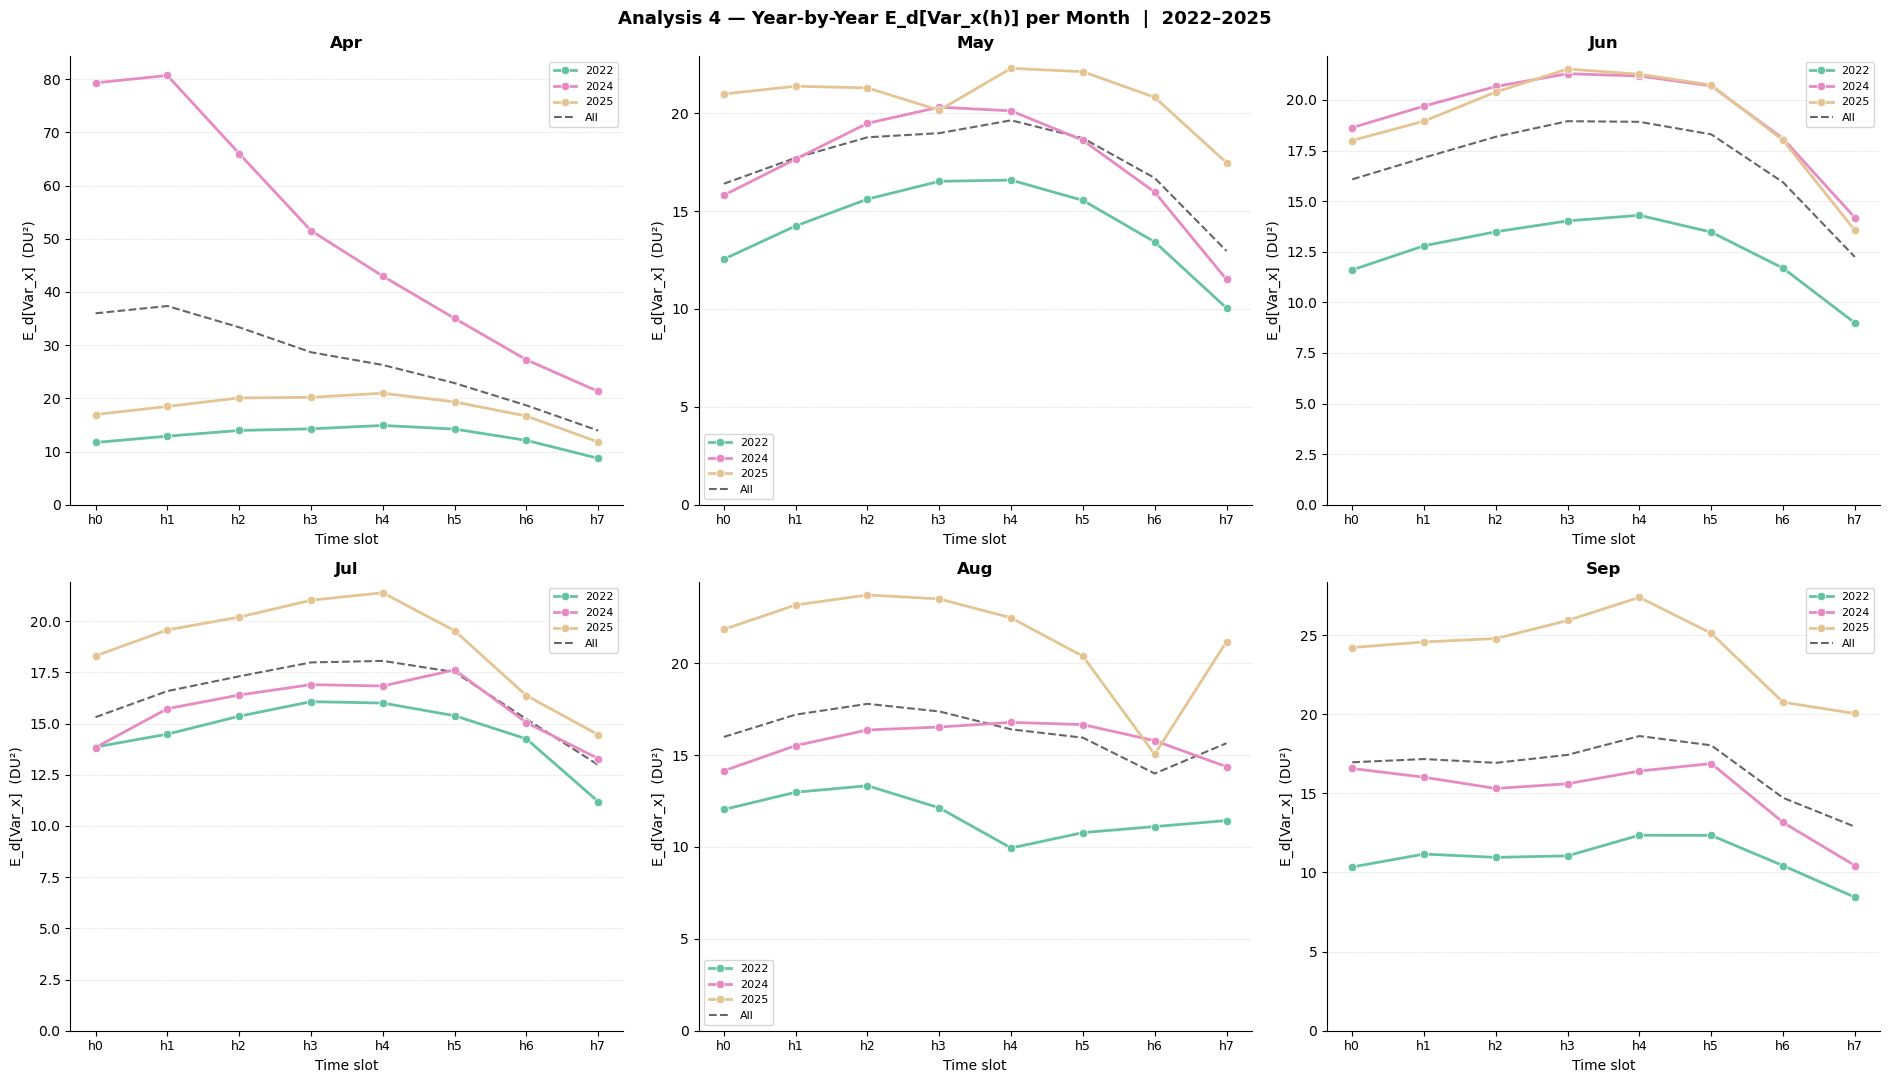

Saved → an4_spatial_var_yearly.png


In [13]:
# ── Analysis 4: Year-by-year E_d[Var_x] per month ────────────────────────────
# 각 월×연도 조합에서 per-day spatial variance 평균
# → 어느 연도가 각 달의 variability를 주도하는지 확인

year_colors = plt.cm.Set2(np.linspace(0, 0.85, len(YEARS)))

# 연도×슬롯 테이블 per month
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
fig.suptitle(
    f'Analysis 4 — Year-by-Year E_d[Var_x(h)] per Month  |  {YEARS[0]}–{YEARS[-1]}',
    fontsize=13, fontweight='bold'
)

for ax, mo in zip(axes.ravel(), MONTHS):
    sub_mo = df[df['month'] == mo]
    for i, yr in enumerate(YEARS):
        sub_yr = sub_mo[sub_mo['year'] == int(yr)]
        if len(sub_yr) == 0:
            continue
        yr_var = sub_yr.groupby('slot')['spatial_var'].mean().reindex(
            range(N_SLOTS)).values.astype(float)
        ax.plot(range(N_SLOTS), yr_var, 'o-',
                color=year_colors[i], lw=2.0, ms=6,
                markeredgecolor='white', markeredgewidth=0.5,
                label=str(yr), zorder=5 + i)
    # All-years mean 기준선
    all_mo = sub_mo.groupby('slot')['spatial_var'].mean().reindex(
        range(N_SLOTS)).values.astype(float)
    ax.plot(range(N_SLOTS), all_mo, 'k--', lw=1.5, alpha=0.6, label='All', zorder=2)

    ax.set_title(MONTH_NAMES[mo], fontsize=12, fontweight='bold')
    ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels(SLOT_LABELS, fontsize=9)
    ax.set_xlabel('Time slot', fontsize=10)
    ax.set_ylabel('E_d[Var_x]  (DU²)', fontsize=10)
    ax.set_ylim(bottom=0)
    ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'an4_spatial_var_yearly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → an4_spatial_var_yearly.png")
